In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
# ==============================================================================
# 1. DATA PREPARATION & TIME-SERIES WINDOWING
# ==============================================================================
df = pd.read_csv("data/processed/cleaned_traffic_features.csv")

# Ensure dataset is chronologically sorted
df['date_time'] = pd.to_datetime(df['date_time'])
df = df.sort_values('date_time').reset_index(drop=True)

feature_cols = [
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'is_weekend', 'is_holiday',
    'is_severe_weather', 'is_low_visibility',
    'temp_scaled', 'clouds_scaled'
]

X_data = df[feature_cols].values
y_data = df['traffic_volume'].values

# Create rolling 3D temporal sequences (Lookback window = 6 hours)
TIME_STEPS = 6

def create_sequences(X, y, time_steps=TIME_STEPS):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i : i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_data, y_data, TIME_STEPS)

# Chronological Train-Test Split (80% Train, 20% Test)
split_idx = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split_idx], X_seq[split_idx:]
y_train_seq, y_test_seq = y_seq[:split_idx], y_seq[split_idx:]

print(f"LSTM Input Training Shape: {X_train_seq.shape}")  # (samples, time_steps, features)
print(f"LSTM Input Testing Shape:  {X_test_seq.shape}")

LSTM Input Training Shape: (38544, 6, 10)
LSTM Input Testing Shape:  (9637, 6, 10)


In [4]:
# ==============================================================================
# 2. BUILD & TRAIN DEEP LEARNING MODEL (LSTM)
# ==============================================================================
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(TIME_STEPS, len(feature_cols))),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)  # Predict traffic volume
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\n--- Training LSTM Model ---")
history = model_lstm.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=25,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate LSTM performance
y_pred_lstm = model_lstm.predict(X_test_seq).flatten()
mae_lstm = mean_absolute_error(y_test_seq, y_pred_lstm)
r2_lstm = r2_score(y_test_seq, y_pred_lstm)

print(f"\n[LSTM Performance] MAE: {mae_lstm:.2f} vehicles/hr | R²: {r2_lstm:.4f}")

C:\Users\TWH\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Training LSTM Model ---
Epoch 1/25
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 13734475.0000 - mae: 3126.2427 - val_loss: 13828536.0000 - val_mae: 3134.1948
Epoch 2/25
543/543 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 10801459.0000 - mae: 2690.1360 - val_loss: 9917839.0000 - val_mae: 2624.7463
Epoch 3/25
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 7286520.5000 - mae: 2243.7212 - val_loss: 6430760.0000 - val_mae: 2172.2390
Epoch 4/25
543/543 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4220956.0000 - mae: 1606.2715 - val_loss: 3154456.2500 - val_mae: 1346.3235
Epoch 5/25
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2085110.6250 - mae: 1057.7439 - val_loss: 1462340.3750 - val_mae: 875.8322
Epoch 6/25
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 1109926.1250 - mae: 748.2861 - val_loss: 811070.5000 - val_mae: 640.5677
Epoch 7/25
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 763960.3750 - mae: 609.5665 - val_loss: 497805.9688 - val_mae: 479.1133
Epoch 8/25
543/543 ━━━━━

In [5]:
# ==============================================================================
# 3. COMPARABLE TREE SURROGATE MODEL FOR EXPLAINABILITY
# ==============================================================================
# Flatten sequence targets for standard tabular model comparison
X_train_tab = df[feature_cols].iloc[TIME_STEPS:split_idx+TIME_STEPS]
y_train_tab = df['traffic_volume'].iloc[TIME_STEPS:split_idx+TIME_STEPS]
X_test_tab = df[feature_cols].iloc[split_idx+TIME_STEPS:]
y_test_tab = df['traffic_volume'].iloc[split_idx+TIME_STEPS:]

rf_surrogate = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_surrogate.fit(X_train_tab, y_train_tab)

y_pred_rf = rf_surrogate.predict(X_test_tab)
mae_rf = mean_absolute_error(y_test_tab, y_pred_rf)
r2_rf = r2_score(y_test_tab, y_pred_rf)

print(f"[RF Surrogate Performance] MAE: {mae_rf:.2f} vehicles/hr | R²: {r2_rf:.4f}")

[RF Surrogate Performance] MAE: 297.82 vehicles/hr | R²: 0.9250



--- Computing SHAP Values ---


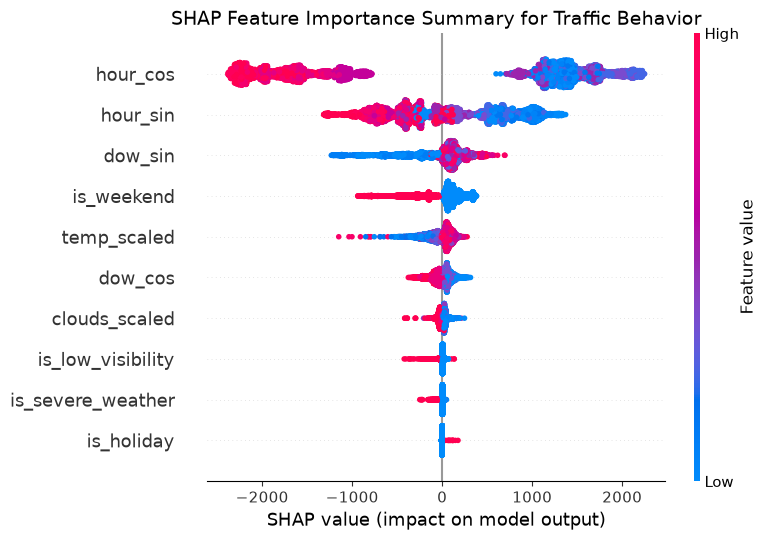

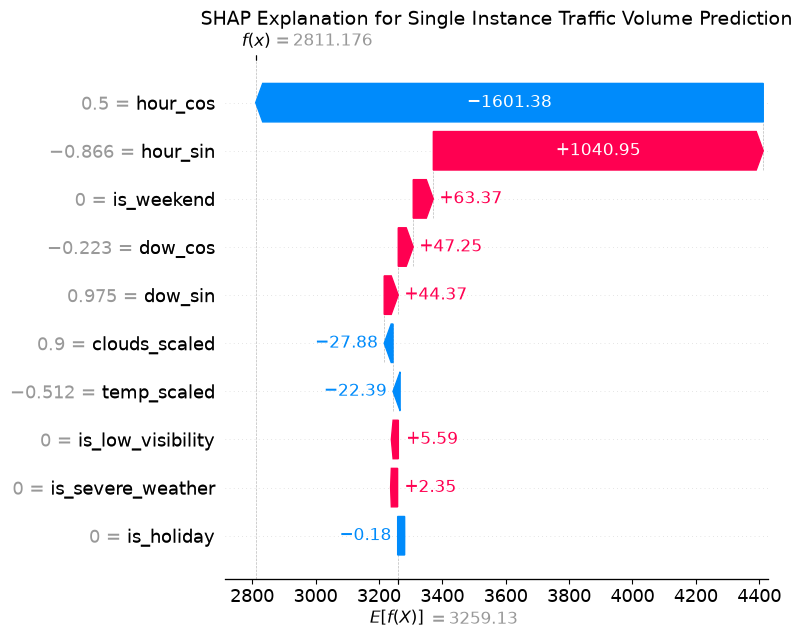

In [6]:
# ==============================================================================
# 4. SHAP EXPLAINABILITY ANALYSIS
# ==============================================================================
print("\n--- Computing SHAP Values ---")
explainer = shap.TreeExplainer(rf_surrogate)
shap_values = explainer(X_test_tab)

# Summary Plot (Feature Impact Distribution)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_tab, show=False)
plt.title("SHAP Feature Importance Summary for Traffic Behavior", fontsize=14)
plt.tight_layout()
plt.show()

# Waterfall Plot for a single instance prediction
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[0], show=False)
plt.title("SHAP Explanation for Single Instance Traffic Volume Prediction", fontsize=14)
plt.tight_layout()
plt.show()